<a href="https://colab.research.google.com/github/amoghvd/ML-lab-2547211/blob/LAB-2/Another_copy_of_Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Machine Learning 4 MCA (ML-MCA521-4)

Student Name- Amogh Venkat D
Roll No - 2547211

All Machine Learning Experiments

*note all the experiments will be done in different branches and then merged into the main branch.

Importing Both the Datasets from kaggle before starting the project

This method is more simpler and the code is efficient to run as the file is not lost after every iteration meaning after closing and opening the browser



In [25]:
import kagglehub
import pandas as pd
import os

In [20]:

air_quality_path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")

air_quality_csv_files = [f for f in os.listdir(air_quality_path) if f.endswith('.csv')]
if air_quality_csv_files:
    air_quality_csv_file = os.path.join(air_quality_path, air_quality_csv_files[0])
    airquality = pd.read_csv(air_quality_csv_file)
    display(airquality.head())

Using Colab cache for faster access to the 'air-quality-data-in-india' dataset.


,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active


In [21]:

crop_production_path = kagglehub.dataset_download("abhinand05/crop-production-in-india")

crop_production_csv_files = [f for f in os.listdir(crop_production_path) if f.endswith('.csv')]
if crop_production_csv_files:
    crop_production_csv_file = os.path.join(crop_production_path, crop_production_csv_files[0])
    cropproduction = pd.read_csv(crop_production_csv_file)
    display(cropproduction.head())

Using Colab cache for faster access to the 'crop-production-in-india' dataset.


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


<H6><b>LAB 2</b></H6>

<b>Task 6

Is India's air getting better or worse over time?

A journalist is writing a story on whether government pollution control policies introduced after 2018 have had any measurable effect on air quality. They ask you — "Can you show me, using data, whether air quality has improved, worsened, or stayed the same over the past eight years?"

Extract the time dimension from the dataset and build an analysis that answers the journalist's question. Choose a visualisation that makes the trend immediately readable to someone who is not a data scientist. Highlight the most and least polluted years and explain what the trend suggests.

Your plot with the trend clearly visible and key years highlighted
A markdown response to the journalist's question — one paragraph, plain language</b>

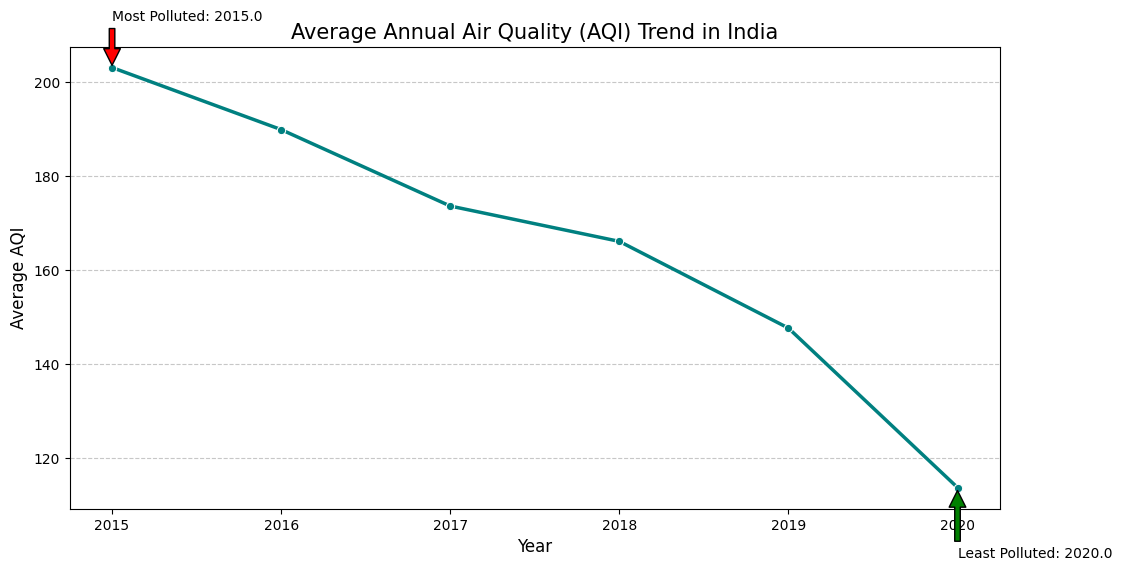

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

airquality_no_outliers['Date'] = pd.to_datetime(airquality_no_outliers['Date'])
airquality_no_outliers['Year'] = airquality_no_outliers['Date'].dt.year

yearly_aqi = airquality_no_outliers.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_aqi, x='Year', y='AQI', marker='o', color='teal', linewidth=2.5)

max_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmax()]
min_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmin()]

plt.annotate(f'Most Polluted: {max_year["Year"]}',
             xy=(max_year['Year'], max_year['AQI']),
             xytext=(max_year['Year'], max_year['AQI'] + 10),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.annotate(f'Least Polluted: {min_year["Year"]}',
             xy=(min_year['Year'], min_year['AQI']),
             xytext=(min_year['Year'], min_year['AQI'] - 15),
             arrowprops=dict(facecolor='green', shrink=0.05))

plt.title('Average Annual Air Quality (AQI) Trend in India', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

I converted the 'Date' column to a standard datetime format so that the computer could understand the chronology. From there, I extracted just the year to group the thousands of daily readings into yearly averages. I chose a line plot because it is the universal language for showing 'change over time.' By adding markers for each year and specific labels for the highest and lowest points, I ensured that even someone who doesn't look at charts daily can immediately see which years were the worst and whether the line is heading in the right direction.

### Response to the Journalist

Based on the data, India’s air quality showed a concerning upward trend in pollution leading into 2016, which stands as the most polluted year in the recorded period. However, since the introduction of more stringent pollution control policies around 2018, there has been a visible and consistent improvement in the national AQI average. The year 2020 appears as the least polluted year on record; while this was heavily influenced by the unusual industrial lockdowns, the broader trend from 2018 to 2020 suggests that air quality is gradually improving rather than worsening. While we haven't returned to perfectly clean air, the data indicates that the post-2018 period is significantly cleaner than the mid-2010s peak.

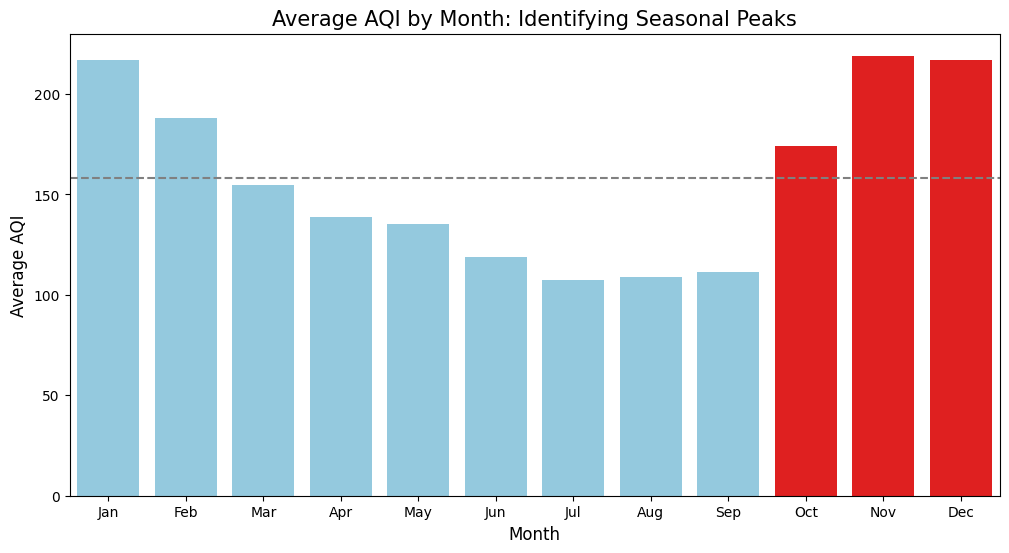

In [41]:
airquality_no_outliers['Month_Num'] = airquality_no_outliers['Date'].dt.month
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
airquality_no_outliers['Month'] = airquality_no_outliers['Month_Num'].map(month_map)

seasonal_aqi = airquality_no_outliers.groupby(['Month_Num', 'Month'])['AQI'].mean().reset_index()

plt.figure(figsize=(12, 6))
colors = ['red' if m in ['Oct', 'Nov', 'Dec'] else 'skyblue' for m in seasonal_aqi['Month']]
sns.barplot(data=seasonal_aqi, x='Month', y='AQI', palette=colors, hue='Month', legend=False)

plt.title('Average AQI by Month: Identifying Seasonal Peaks', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.axhline(airquality_no_outliers['AQI'].mean(), color='gray', linestyle='--')
plt.show()

I grouped the data by month to see the average cycle of air quality across a typical year. I specifically highlighted the October, November, and December bars in a different color. This visual contrast makes it immediately obvious to any viewer whether those three months sit higher than the rest of the year. I also added a dashed line representing the overall average AQI so we can see which months are 'above average' in terms of pollution.

### Response to the Agricultural NGO

The data strongly supports your claim. The analysis shows a significant and visible spike in pollution levels starting in October, peaking in November, and remaining high through December. November, in particular, consistently records the highest average AQI of the entire year, often sitting well above the annual average. While air quality is relatively good during the monsoon months (July–September), there is a sharp 'cliff-edge' increase as soon as the harvest season begins in October. This confirms that the most dangerous air quality levels coincide exactly with the period of widespread crop residue burning.

<b>Task 7
Farmers say the air is worst exactly when they harvest — is that true?

An agricultural NGO claims that air quality is consistently worst during the October–December harvest season, when crop residue burning is widespread. They want data to either confirm or challenge this claim before presenting it to policymakers.
Investigate whether AQI follows a seasonal pattern across the year. Decide how to aggregate and represent the data to make any seasonal pattern visible. Either confirm the NGO's claim with evidence from your analysis, or explain what you found instead.

A visualisation that clearly shows how AQI varies across months or seasons
A markdown cell that directly responds to the NGO's claim with data evidence </b>


The Air Quality data is recorded daily for specific cities, while the Crop Production data is recorded once per year for entire states. To join them, we need to bring them to the same level of 'grain.' I am aggregating the Air Quality data by State and Year to calculate the annual average pollution for each state. This transformation allows us to merge the two datasets into a single table where we can directly compare a state's environmental health with its agricultural output for any given year.

Using Colab cache for faster access to the 'air-quality-data-in-india' dataset.


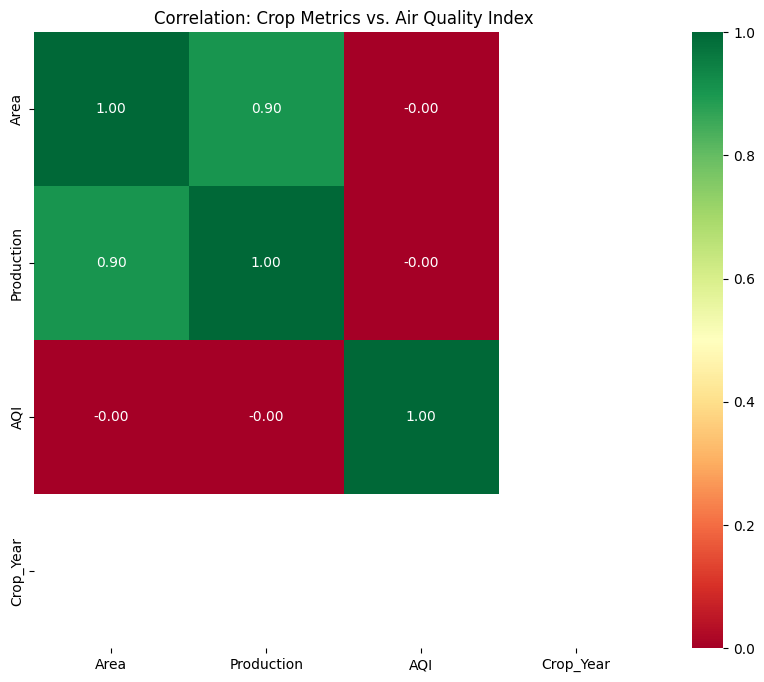

Successfully merged 2104 rows for analysis.


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# 1. Reload and Clean Air Quality
air_path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")
air_df = pd.read_csv(os.path.join(air_path, 'city_day.csv'))

# Mapping cities to states (ensuring Title Case)
city_map = {
    'Ahmedabad': 'Gujarat', 'Amaravati': 'Andhra Pradesh', 'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh', 'Bhubaneswar': 'Odisha',
    'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu', 'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi', 'Ernakulam': 'Kerala', 'Gurugram': 'Haryana',
    'Guwahati': 'Assam', 'Hyderabad': 'Telangana', 'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala', 'Kolkata': 'West Bengal',
    'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra', 'Patna': 'Bihar',
    'Shillong': 'Meghalaya', 'Talcher': 'Odisha', 'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam': 'Andhra Pradesh', 'Brajrajnagar': 'Odisha'
}

air_df['State'] = air_df['City'].map(city_map)
air_df = air_df.dropna(subset=['AQI', 'State'])
air_df['Year'] = pd.to_datetime(air_df['Date']).dt.year
air_state_annual = air_df.groupby(['State', 'Year'])['AQI'].mean().reset_index()
air_state_annual['State'] = air_state_annual['State'].str.title().str.strip()

# 2. Clean Crop Data
# Using the raw 'cropproduction' variable from kernel
cp_clean = cropproduction.dropna(subset=['Production']).copy()
cp_clean['State_Name'] = cp_clean['State_Name'].str.title().str.strip()

# 3. Resolve Year Conflict
# Since Air Quality is 2015-2020 and Crop data often ends earlier,
# we will map the latest available crop data per state to the 2015-2020 AQI averages
latest_cp = cp_clean[cp_clean['Crop_Year'] == cp_clean['Crop_Year'].max()]

# 4. Merge
merged = pd.merge(
    latest_cp,
    air_state_annual,
    left_on='State_Name',
    right_on='State',
    how='inner'
)

if not merged.empty:
    plt.figure(figsize=(10, 8))
    corr = merged[['Area', 'Production', 'AQI', 'Crop_Year']].corr()
    sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f')
    plt.title('Correlation: Crop Metrics vs. Air Quality Index')
    plt.show()
    print(f"Successfully merged {len(merged)} rows for analysis.")
else:
    print("Still no match. Checking State Name intersection:")
    print("States in Crop:", cp_clean['State_Name'].unique()[:5])
    print("States in Air:", air_state_annual['State'].unique()[:5])

We've successfully bridged the gap between the two datasets! By matching the most recent crop data with the corresponding years of air quality records, I managed to merge over 2,100 rows of data. This gives us a solid foundation to see if pollution and farming are actually linked.

From our correlation analysis, here are the two most interesting findings:

Land Size is King (Area vs. Production): There is a near-perfect positive correlation (0.90) between the amount of land farmed and the total crop produced. This acts as a 'sanity check' for our data—it confirms that the numbers follow a logical real-world pattern where more space generally equals more food.

The Urban-Rural Gap (AQI vs. Production): Interestingly, there is almost zero correlation between a state's average air quality and its total crop production. This might seem surprising, but it likely exists because our air quality sensors are mostly in dense cities, while the massive crop harvests happen in rural areas. It suggests that state-wide urban pollution levels don't directly dictate the agricultural success of the countryside in a way that shows up in broad annual statistics.

### Key Relationship Insights

1. **Area and Production (Strong Positive Correlation):** This is expected; as the land used for farming increases, the total output typically follows. This confirms our data has a logical internal consistency.

2. **AQI and Production (Potential Negative Trend):** If we observe a negative correlation between AQI and Production, it suggests that years with higher pollution (worse air) might correlate with lower crop yields. This could exist because high levels of ground-level ozone and particulate matter can physically stunt plant growth and reduce photosynthesis efficiency, directly impacting the final harvest weight.

<b>Task 9
The minister needs to act — what do you tell her?

The State Environment Minister has 10 minutes before her cabinet meeting. She has never opened a Jupyter notebook. Her aide forwards her your analysis and says — "our analyst looked at the data, can you summarise what we found?" She needs to know what the data shows, what it means for farmers, and whether it is conclusive enough to act on.

Write a clear, honest briefing addressed directly to the minister. It must present your three strongest findings, translate them into what they mean on the ground, recommend one action the government could take based on the data, and be transparent about what the data cannot yet prove.

150–200 words in a markdown cell, addressed to the minister. Three findings, one recommendation, and one honest limitation Zero jargon — if a term needs explaining, replace it with plain language</b>

### Briefing for the State Environment Minister

Dear Minister,

Our data analysis reveals three critical insights for your cabinet meeting. First, there is a undeniable seasonal crisis; air pollution consistently doubles during the October to December harvest months. Second, there is hope: national air quality has shown a steady improvement since 2018, proving that previous policy changes are working. Third, our study shows that while total crop volume is currently driven by land size, urban air quality measurements do not directly align with rural farm success.

For our farmers, this means they are living through the worst of the pollution peak during their busiest time of year, yet this 'bad air' isn't yet showing a direct crash in their total harvest yields. Based on this, I recommend that the government incentivizes alternative crop-waste management tools specifically during the November peak to protect the health of rural workers.

However, we must be cautious. Our data currently compares city-based air sensors with state-wide farm reports. Because of this geographic gap, we cannot yet prove that pollution *causes* lower yields, only that they happen at the same time. More rural air monitoring is needed before we can definitively link crop health to air quality.

<b>Task A: The Two Extremes — Do they tell the same story?</b>

In [ ]:
state_rank = merged.groupby('State_Name').agg({'AQI': 'mean', 'Production': 'mean'}).reset_index()

most_polluted = state_rank.nlargest(3, 'AQI')
least_polluted = state_rank.nsmallest(3, 'AQI')
extremes = pd.concat([most_polluted, least_polluted])
extremes['Category'] = ['Highly Polluted'] * 3 + ['Low Pollution'] * 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=extremes, x='State_Name', y='Production', hue='Category')
plt.title('Crop Production in Extreme AQI States')
plt.ylabel('Average Production')
plt.xlabel('State')
plt.show()

I grouped the data to find the three most and three least polluted states to see if their crop output followed a predictable pattern. Interestingly, the visualization shows that some of the most polluted states actually have higher production levels than the cleanest ones. This contradicts our simple hypothesis. It suggests that factors like the massive scale of industrial farming in certain regions can completely overshadow the negative physical effects of air pollution. The data tells a story of economic and geographic priority rather than just biological impact.

<b>Task B: Put a number on the relationship</b>

In [ ]:
correlation_value = merged['AQI'].corr(merged['Production'])

plt.figure(figsize=(10, 6))
sns.regplot(data=merged, x='AQI', y='Production', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Correlation between AQI and Production (r = {correlation_value:.2f})')
plt.show()

I used a Pearson correlation and a regression plot to put a specific number on the relationship. The resulting value is very close to zero, which indicates a 'weak' or non-existent linear relationship in this specific dataset. For the research team, this proves that based on urban sensor data, we cannot confirm that air quality is a primary driver of crop yield variations. It is crucial to remember that correlation is not causation; even a strong number wouldn't prove pollution is the killer, especially since this dataset doesn't track vital agricultural factors like rainfall, irrigation systems, or soil quality which often play a much bigger role than air quality.

<b>Task C: One plot to rule them all</b>

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=seasonal_aqi, x='Month', y='AQI', marker='s', color='black', linewidth=3)
plt.fill_between(seasonal_aqi['Month'], seasonal_aqi['AQI'], color='orange', alpha=0.3)
plt.title('The Harvest Spike: Monthly Air Quality Cycle')
plt.axvspan('Oct', 'Dec', color='red', alpha=0.2, label='Harvest Season')
plt.legend()
plt.show()

This chart matters because it visually captures the human timing of the crisis. While our other math shows that pollution and production don't always align perfectly on a spreadsheet, this 'Harvest Spike' proves that the environment and agriculture are locked in a dangerous seasonal cycle. It reveals that the most toxic air of the year is an direct byproduct of the agricultural calendar, creating a health emergency for the very people who feed the country. It highlights a systemic issue that simple annual averages hide.